# Steam Game Reviews & Popularity Analysis
## Finale Projeknotaboek — Al 4 Fases

**Onderwerp:** Hoe kan 'n speletjie-ontwikkelaar hul speletjie in 'n spesifieke genre suksesvol maak op Steam, gebaseer op resensies, gewildheid en genre-verwantskappe?

**Datastel:** 33 speletjies oor 9 genres, ~65 000 skoon resensies (Julie 2025 – Julie 2026)

**Databronne:** Steam API (resensies, app-besonderhede, huidige spelersgetalle)

**Tegnologieë:** Python 3, pandas, numpy, matplotlib, seaborn, scikit-learn, vaderSentiment, wordcloud, networkx, pyarrow, streamlit


---
## Fase 1: Projekdokument

### Navorsingsvraag
*Hoe kan 'n speletjie-ontwikkelaar hul speletjie in 'n spesifieke genre suksesvol maak op Steam?*

### Hipotese
Genre bepaal die basislyn-verwagtinge van spelers. Suksesfaktore (speeltyd, resensielengte, prys, opdateringsfrekwensie) verskil beduidend tussen genres. 'n Ontwikkelaar moet hul mededingers binne hul teikengenre meet, nie die hele speletjiemark nie. 'n 70% positiewe resensiescore kan uitstekend wees vir 'n Free-to-Play-speletjie, maar teleurstellend vir 'n Action-RPG.

### Relevansie vir Belanghebbendes
Steam is die grootste PC-speletjieplatform met 132 miljoen maandelikse aktiewe gebruikers en 50 000+ speletjies. Die projek se insigte is relevant vir:
- **Speletjie-ontwikkelaars (veral indie):** Verstaan watter faktore positiewe resensies in hul teikengenre aandryf.
- **Uitgewers:** Neem ingeligte besluite oor watter genre om in te belê.
- **Beleggers:** Evalueer potensiële sukses gebaseer op genre-spesifieke maatstawwe.
- **Navorsers:** Verstaan die verband tussen speletjiekenmerke, spelertevredenheid en langtermynsukses.

### Databronne en Tegnieke
- **Steam API** – resensies, speletjiebesonderhede, huidige spelersgetalle
- **Tegnieke:** NLP (VADER, TF-IDF, woordwolke), Netwerkanalise (genre-verwantskappe, kommentaar-ooreenkoms, woordnetwerke), Regressie (lineêr, logisties), Interaktiewe Streamlit-dashboard

### Etiese Oorwegings en Haalbaarheid
Slegs openbare data word gebruik (Steam API). Geen privaatgebruikersinligting word gestoor nie. Alle tegnieke is binne kursusbestek. Data is vrylik beskikbaar en die projek is haalbaar binne 'n semester.

**Vir die volledige Fase 1-dokument, sien** `Fase1_Projek.ipynb`. Die res van hierdie notaboek bevat die tegniese implementering (Fase 2-4).

---
### Invoere en Opstelling

In [6]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

from src.utils import GAMES, GAME_IDS, RAW_DIR, PROCESSED_DIR, GENRES, GENRE_IDS, GAME_GENRES, games_by_genre, games_in_genres
from src import scrape
from src import clean
from src import eda
from src import nlp_analysis
from src import regression
from src import network

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)

print('Alle modules suksesvol ingevoer.')
print(f'{len(GAMES)} speletjies, {len(GENRES)} genres')


Alle modules suksesvol ingevoer.
33 speletjies, 9 genres


---
## Fase 2: Data Insameling en Verwerking

**Nota:** Hierdie notebook kan alle data van nuut af skraap as dit nie reeds bestaan nie.
As `data/raw/reviews.csv` reeds 33 speletjies se data bevat, word dit net gelaai.
Om van nuut af te skraap, verwyder die lêers in `data/raw/` en `data/processed/`.
Skraping neem +-30 minute weens Steam API se 0.3s vertraging per versoek.


In [7]:
# 2.0 Oorsig van speletjies en genres
print('Speletjies:', len(GAMES))
print('Genres:', ', '.join(GENRES.keys()))
for genre, ids in GENRES.items():
    names = [GAMES[a] for a in ids]
    print(f'  {genre}: {len(ids)} speletjies — {', '.join(names)}')


Speletjies: 33
Genres: RPG, Shooter, Hero_Shooter, Battle_Royale, Action, Strategy, Adventure, Survival, Free_to_Play
  RPG: 8 speletjies — Baldur's Gate 3, Cyberpunk 2077, Elden Ring, The Witcher 3, Skyrim SE, Dragon's Dogma 2, Fallout 4, Valheim
  Shooter: 11 speletjies — Counter-Strike 2, PUBG: BATTLEGROUNDS, Helldivers 2, Call of Duty HQ, Overwatch 2, Apex Legends, Destiny 2, Rainbow Six Siege, Battlefield 2042, Team Fortress 2, Paladins
  Hero_Shooter: 4 speletjies — Overwatch 2, Marvel Rivals, Team Fortress 2, Paladins
  Battle_Royale: 4 speletjies — PUBG: BATTLEGROUNDS, Call of Duty HQ, Apex Legends, Fall Guys
  Action: 17 speletjies — Elden Ring, Cyberpunk 2077, No Man's Sky, Helldivers 2, Ghost of Tsushima, God of War, Red Dead Redemption 2, Devil May Cry 5, The Witcher 3, Skyrim SE, Dragon's Dogma 2, Fallout 4, Team Fortress 2, Rust, ARK: Survival Evolved, Valheim, The Forest
  Strategy: 6 speletjies — Baldur's Gate 3, Stellaris, Sid Meier's Civilization VI, Total War: WARHAM

In [8]:
# 2.1 Skraap resensies van Steam API (slaan oor as data reeds bestaan)
raw_path = f'{RAW_DIR}/reviews.csv'
clean_path = f'{PROCESSED_DIR}/reviews_clean.csv'

should_scrape = False
if not os.path.exists(raw_path):
    print('Geen rou data gevind. Skraper nuwe data...')
    should_scrape = True
else:
    df_raw_check = pd.read_csv(raw_path)
    scraped_games = set(df_raw_check['app_id'].unique())
    missing_games = [a for a in GAME_IDS if a not in scraped_games]
    if missing_games:
        print(f'Onvolledige data: {len(missing_games)} speletjies kort. Skraper...')
        should_scrape = True
    else:
        print(f'{len(df_raw_check)} resensies vir {len(scraped_games)} speletjies gelaai.')

if should_scrape:
    # Skraap al 33 speletjies — neem ~20-30 minute
    # Eers: skraap resensies een vir een en stoor progressief
    print('Skraap besig... (hierdie kan lank neem)')
    all_reviews = []
    for app_id in GAME_IDS:
        name = GAMES[app_id]
        print(f'{name}...', end=' ', flush=True)
        reviews = scrape.scrape_reviews(app_id)
        if reviews:
            all_reviews.extend(reviews)
            print(f'{len(reviews)} resensies')
        else:
            print('geen')
    
    df_reviews = pd.DataFrame(all_reviews)
    df_reviews.to_csv(raw_path, index=False)
    print(f'\nGestoor: {len(df_reviews)} resensies na {raw_path}')
    
    # Skraap app details en huidige spelersgetalle
    print('\nLaai app besonderhede...')
    from src.scrape import fetch_app_details, fetch_player_count
    import time as _time
    app_details = []
    for app_id in GAME_IDS:
        details = fetch_app_details(app_id)
        if details:
            app_details.append(details)
        _time.sleep(0.3)
    pd.DataFrame(app_details).to_csv(f'{RAW_DIR}/app_details.csv', index=False)
    print(f'App besonderhede gestoor: {len(app_details)} speletjies')
    
    player_counts = []
    for app_id in GAME_IDS:
        pc = fetch_player_count(app_id)
        if pc:
            player_counts.append(pc)
        _time.sleep(0.3)
    pd.DataFrame(player_counts).to_csv(f'{RAW_DIR}/player_counts.csv', index=False)
    print(f'Spelersgetalle gestoor: {len(player_counts)} speletjies')


161630 resensies vir 33 speletjies gelaai.


In [9]:
# 2.2 Skoonmaak en genre-kenmerke
df_clean, _ = clean.process_reviews()
print(f'Datumbereik: {df_clean["review_date"].min()} tot {df_clean["review_date"].max()}')
print(f'Speletjies: {df_clean["app_id"].nunique()}')
print(f'Rye: {len(df_clean)}, Kolomme: {len(df_clean.columns)}')


Loaded 161630 raw reviews
After cleaning: 159768 reviews
Saved clean reviews to /mnt/c/Users/V/Desktop/Data Analise Project/data/processed/reviews_clean.csv
  Elden Ring               :   4991 reviews,  95.1% positive
  Baldur's Gate 3          :   4988 reviews,  94.9% positive
  Counter-Strike 2         :   4976 reviews,  54.8% positive
  Overwatch 2              :   4996 reviews,  37.4% positive
  Marvel Rivals            :   4995 reviews,  30.6% positive
  Cyberpunk 2077           :   4993 reviews,  95.5% positive
  No Man's Sky             :   4999 reviews,  87.7% positive
  PUBG: BATTLEGROUNDS      :   4985 reviews,  48.8% positive
  Call of Duty HQ          :   4988 reviews,  22.9% positive
  Helldivers 2             :   4989 reviews,  17.5% positive
  The Witcher 3            :   4995 reviews,  95.9% positive
  Skyrim SE                :   4990 reviews,  97.3% positive
  Dragon's Dogma 2         :   4996 reviews,  59.1% positive
  Fallout 4                :   4999 reviews,  33.2

In [12]:
# 2.3 VADER-sentimentanalise
if 'vader_compound' not in df_clean.columns:
    print('VADER word bereken (neem n paar minute vir 65k resensies)...')
    df_clean = nlp_analysis.apply_vader(df_clean)
    df_clean.to_csv(clean_path, index=False)
    print('VADER voltooi en gestoor.')
else:
    print('VADER kolomme bestaan reeds.')

vader_cols = [c for c in df_clean.columns if 'vader' in c]
print(f'VADER kolomme: {vader_cols}')


VADER word bereken (neem n paar minute vir 65k resensies)...
VADER voltooi en gestoor.
VADER kolomme: ['vader_compound', 'vader_positive', 'vader_neutral', 'vader_negative', 'vader_sentiment_label']


In [13]:
# 2.4 Datakwaliteit opsomming
print('=== Datakwaliteit ===')
print(f'Resensies: {len(df_clean)}')
print(f'Speletjies: {df_clean["app_id"].nunique()}/{len(GAMES)}')
print(f'Tale: {df_clean["language"].nunique()}')
genre_cols = [c for c in df_clean.columns if c.startswith('genre_')]
print(f'Genre-kolomme ({len(genre_cols)}): {genre_cols}')


=== Datakwaliteit ===
Resensies: 159768
Speletjies: 33/33
Tale: 30
Genre-kolomme (9): ['genre_RPG', 'genre_Shooter', 'genre_Hero_Shooter', 'genre_Battle_Royale', 'genre_Action', 'genre_Strategy', 'genre_Adventure', 'genre_Survival', 'genre_Free_to_Play']


In [14]:
# 2.5 English-only filter vir NLP
df_en = df_clean[df_clean['language'] == 'english'].copy()
print(f'English resensies: {len(df_en)} / {len(df_clean)} ({100*len(df_en)/len(df_clean):.1f}%)')


English resensies: 78918 / 159768 (49.4%)


---
## Fase 3: Verkennende Data Analise (EDA)

In [16]:
# Basiese statistieke
stats = eda.basic_statistics(df_clean)
print('=== Algemene Statistieke ===')
for k, v in stats.items():
    print(f'  {k}: {v}')


=== Algemene Statistieke ===
  total_reviews: 159768
  positive_reviews: 108603
  negative_reviews: 51165
  positive_pct: 67.98
  avg_playtime: 20725.9
  median_playtime: 6900.0
  avg_review_length: 417.7
  median_review_length: 186.0
  avg_word_count: 69.9
  date_range: 2016-09-17 to 2026-07-17
  num_games: 33
  num_languages: 30


In [17]:
# Per-speletjie statistieke
per_game = eda.per_game_statistics(df_clean)
print('=== Per Speletjie ===')
display(per_game)


=== Per Speletjie ===


,game,total_reviews,positive,negative,positive_pct,avg_playtime,avg_review_length,avg_word_count,steam_purchase_pct
0,Elden Ring,4991,4747,244,95.1,12996.0,506.0,80.8,65.7
1,Baldur's Gate 3,4988,4735,253,94.9,17138.0,545.0,89.1,86.1
2,Counter-Strike 2,4976,2727,2249,54.8,53469.0,335.0,54.0,100.0
3,Overwatch 2,4996,1867,3129,37.4,17584.0,409.0,70.9,100.0
4,Marvel Rivals,4995,1529,3466,30.6,29935.0,528.0,91.7,100.0
...,...,...,...,...,...,...,...,...,...
28,Age of Empires IV,4967,3416,1551,68.8,18484.0,240.0,39.3,78.5
29,Rust,4988,3562,1426,71.4,47288.0,312.0,54.2,85.1
30,ARK: Survival Evolved,4997,2998,1999,60.0,25819.0,306.0,53.3,75.5
31,Valheim,4996,4222,774,84.5,17302.0,504.0,85.0,80.1


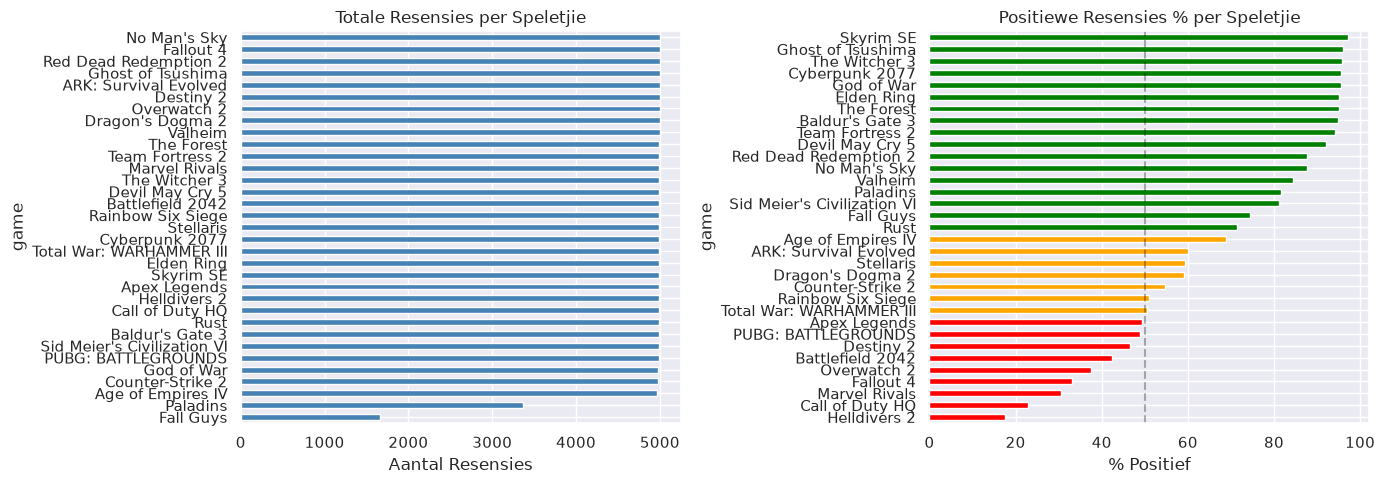

In [18]:
# Visualisasi: Resensie volume per speletjie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = per_game.sort_values('total_reviews', ascending=True).plot(
    x='game', y='total_reviews', kind='barh', ax=axes[0],
    color='steelblue', legend=False
)
axes[0].set_title('Totale Resensies per Speletjie')
axes[0].set_xlabel('Aantal Resensies')

ax2 = per_game.sort_values('positive_pct', ascending=True).plot(
    x='game', y='positive_pct', kind='barh', ax=axes[1],
    color=['green' if v > 70 else 'orange' if v > 50 else 'red' for v in per_game.sort_values('positive_pct')['positive_pct']],
    legend=False
)
axes[1].set_title('Positiewe Resensies % per Speletjie')
axes[1].set_xlabel('% Positief')
axes[1].axvline(50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
# Per-genre statistieke
per_genre = eda.per_genre_statistics(df_clean)
print('=== Per Genre ===')
display(per_genre)


=== Per Genre ===


,genre,total_reviews,positive,negative,positive_pct,avg_playtime,avg_review_length,avg_word_count,num_games
0,RPG,39948,32730,7218,81.9,13369.0,511.0,84.0,8
1,Shooter,53276,25942,27334,48.7,29576.0,384.0,65.4,11
2,Hero Shooter,18357,10852,7505,59.1,22988.0,370.0,64.0,4
3,Battle Royale,16622,7272,9350,43.7,26802.0,274.0,45.1,4
4,Action,84895,67791,17104,79.9,14129.0,466.0,77.6,17
5,Strategy,29921,20224,9697,67.6,24876.0,371.0,62.1,6
6,Adventure,54936,46325,8611,84.3,12279.0,452.0,75.1,11
7,Survival,24975,19911,5064,79.7,20857.0,392.0,66.5,5
8,Free to Play,34967,19708,15259,56.4,29924.0,325.0,54.6,8


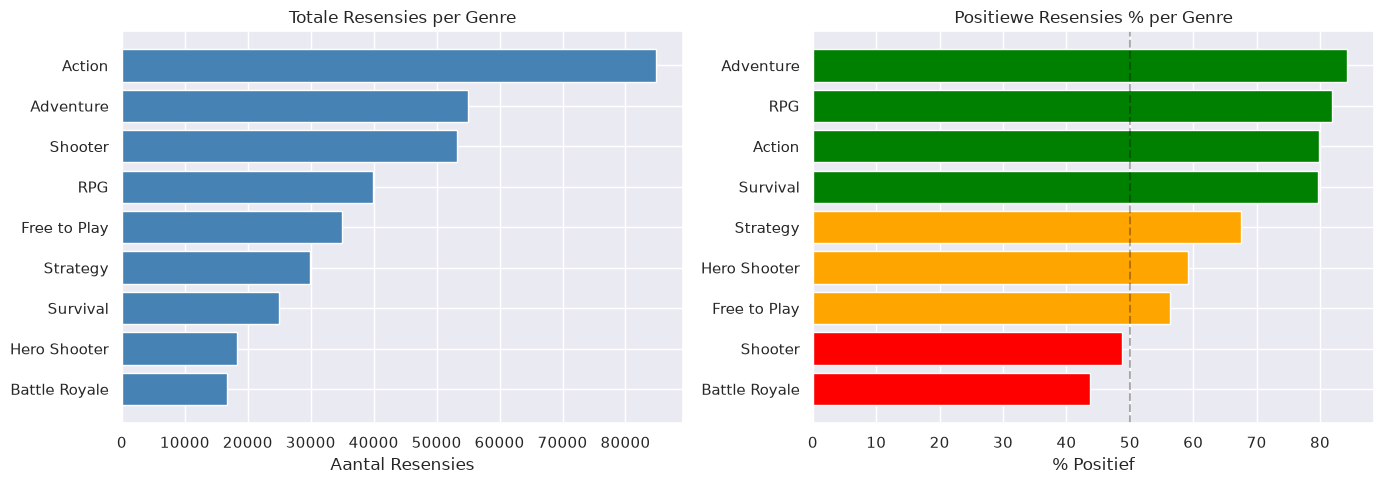

In [20]:
# Visualisasie: Resensies per genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

per_genre_sorted = per_genre.sort_values('total_reviews', ascending=True)
axes[0].barh(per_genre_sorted['genre'], per_genre_sorted['total_reviews'], color='steelblue')
axes[0].set_title('Totale Resensies per Genre')
axes[0].set_xlabel('Aantal Resensies')

per_genre_pct = per_genre.sort_values('positive_pct', ascending=True)
colors_g = ['green' if v > 70 else 'orange' if v > 50 else 'red' for v in per_genre_pct['positive_pct']]
axes[1].barh(per_genre_pct['genre'], per_genre_pct['positive_pct'], color=colors_g)
axes[1].set_title('Positiewe Resensies % per Genre')
axes[1].set_xlabel('% Positief')
axes[1].axvline(50, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


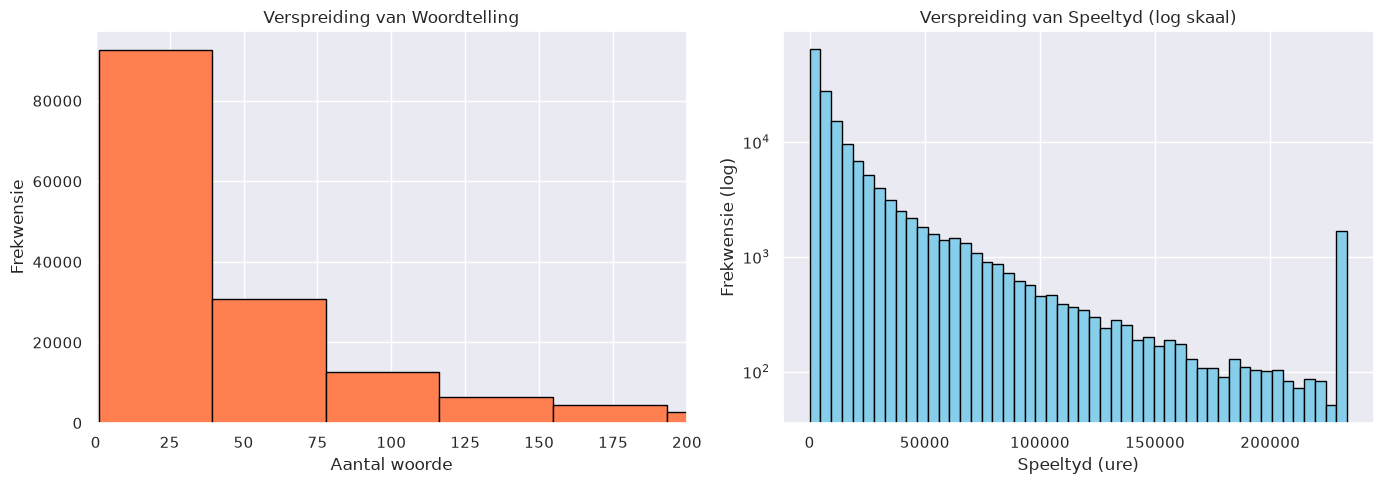

In [21]:
# Resensie lengte verspreiding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_clean['word_count'].hist(bins=50, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Verspreiding van Woordtelling')
axes[0].set_xlabel('Aantal woorde')
axes[0].set_ylabel('Frekwensie')
axes[0].set_xlim(0, 200)

df_clean['playtime_forever'].hist(bins=50, ax=axes[1], color='skyblue', edgecolor='black', log=True)
axes[1].set_title('Verspreiding van Speeltyd (log skaal)')
axes[1].set_xlabel('Speeltyd (ure)')
axes[1].set_ylabel('Frekwensie (log)')

plt.tight_layout()
plt.show()


### 3.1 Formele Statistiese Toetse

In [22]:
t1 = eda.review_length_sentiment_test(df_clean)
if t1:
    print(f"=== {t1['test']} ===")
    print(f"  Veranderlike: {t1['variable']}")
    print(f"  Positief gem: {t1['positive_mean']} woorde")
    print(f"  Negatief gem: {t1['negative_mean']} woorde")
    print(f"  t-statistiek: {t1['t_statistic']}")
    print(f"  p-waarde: {t1['p_value']}")
    print(f"  Beduidend: {t1['significant']}")


=== Welch's t-test ===
  Veranderlike: word_count by voted_up
  Positief gem: 64.48 woorde
  Negatief gem: 81.37 woorde
  t-statistiek: -24.3231
  p-waarde: 3.12e-130
  Beduidend: True


In [23]:
t2 = eda.playtime_sentiment_test(df_clean)
if t2:
    print(f"=== {t2['test']} ===")
    print(f"  Veranderlike: {t2['variable']}")
    print(f"  Positief gem: {t2['positive_mean']} ure")
    print(f"  Negatief gem: {t2['negative_mean']} ure")
    print(f"  t-statistiek: {t2['t_statistic']}")
    print(f"  p-waarde: {t2['p_value']}")
    print(f"  Beduidend: {t2['significant']}")


=== Welch's t-test ===
  Veranderlike: playtime_forever by voted_up
  Positief gem: 17459.7 ure
  Negatief gem: 27658.86 ure
  t-statistiek: -46.1567
  p-waarde: 0.00e+00
  Beduidend: True


In [24]:
# ANOVA: Verskil resensielengte beduidend tussen genres?
genre_groups = []
genre_labels = []
for genre in GENRE_IDS:
    g = df_clean[df_clean[f'genre_{genre}'] == 1]['word_count'].values
    if len(g) > 1:
        genre_groups.append(g)
        genre_labels.append(genre)

from scipy import stats
if len(genre_groups) >= 2:
    f_stat, p_val = stats.f_oneway(*genre_groups)
    print(f"=== One-way ANOVA: word_count by genre ===")
    print(f"  Aantal genres: {len(genre_groups)}")
    print(f"  F-statistiek: {f_stat:.4f}")
    print(f"  p-waarde: {p_val:.2e}")
    print(f"  Beduidend: {p_val < 0.05}")
    print(f"\nInterpreting: Resensielengtes verskil {'wel' if p_val < 0.05 else 'nie'} beduidend tussen genres.")
    
    # Watter genre het die langste resensies?
    means = [(genre_labels[i], g.mean()) for i, g in enumerate(genre_groups)]
    means.sort(key=lambda x: x[1], reverse=True)
    print(f"\nLangste resensies (gem. woorde):")
    for name, m in means[:5]:
        print(f"  {name}: {m:.1f}")


=== One-way ANOVA: word_count by genre ===
  Aantal genres: 9
  F-statistiek: 312.2413
  p-waarde: 0.00e+00
  Beduidend: True

Interpreting: Resensielengtes verskil wel beduidend tussen genres.

Langste resensies (gem. woorde):
  RPG: 84.0
  Action: 77.6
  Adventure: 75.1
  Survival: 66.5
  Shooter: 65.4


In [25]:
# Korrelasie analise
corr = eda.correlation_analysis(df_clean)
print('=== Korrelasiematriks ===')
display(corr.style.background_gradient(cmap='coolwarm', axis=None).format('{:.3f}'))


=== Korrelasiematriks ===


,playtime_forever,review_length,word_count,votes_up,num_games_owned,num_reviews
playtime_forever,1.000,0.042,0.044,0.046,-0.029,-0.026
review_length,0.042,1.000,0.979,0.076,0.112,0.076
word_count,0.044,0.979,1.000,0.072,0.100,0.065
votes_up,0.046,0.076,0.072,1.000,0.029,0.005
num_games_owned,-0.029,0.112,0.100,0.029,1.000,0.445
num_reviews,-0.026,0.076,0.065,0.005,0.445,1.000


---
## Fase 4: Diepgaande Analise

### 4.1 Natuurlike Taalverwerking (NLP)

In [29]:
# VADER sentiment analise (English only)
print('Applying VADER sentiment analysis on English reviews...')
if 'vader_compound' not in df_en.columns:
    df_vader = nlp_analysis.apply_vader(df_en)
else:
    df_vader = df_en.copy()
print(f'VADER completed on {len(df_vader)} English reviews')
agreement, df_vader = nlp_analysis.sentiment_agreement(df_vader)
print(f'\nSentiment agreement rate (VADER vs Steam thumbs-up): {agreement:.1%}')


Applying VADER sentiment analysis on English reviews...
VADER completed on 78918 English reviews

Sentiment agreement rate (VADER vs Steam thumbs-up): 49.8%


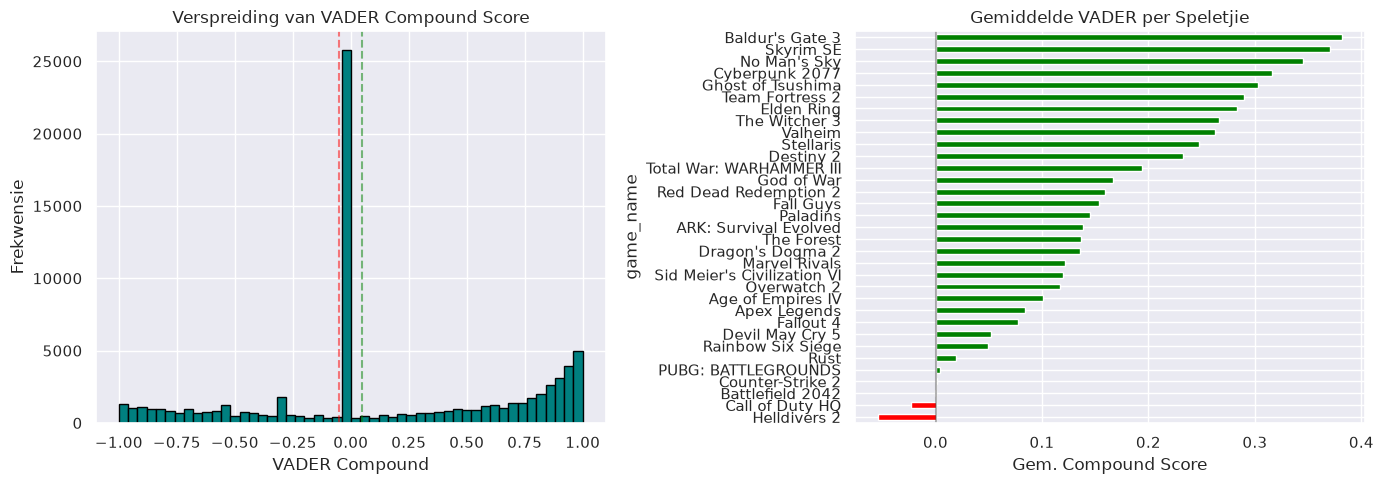

In [30]:
# VADER verspreiding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_vader['vader_compound'].hist(bins=50, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Verspreiding van VADER Compound Score')
axes[0].set_xlabel('VADER Compound')
axes[0].set_ylabel('Frekwensie')
axes[0].axvline(-0.05, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(0.05, color='green', linestyle='--', alpha=0.5)

sentiments = df_vader.groupby('game_name')['vader_compound'].mean().sort_values()
colors = ['red' if v < 0 else 'green' for v in sentiments.values]
sentiments.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Gemiddelde VADER per Speletjie')
axes[1].set_xlabel('Gem. Compound Score')
axes[1].axvline(0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()


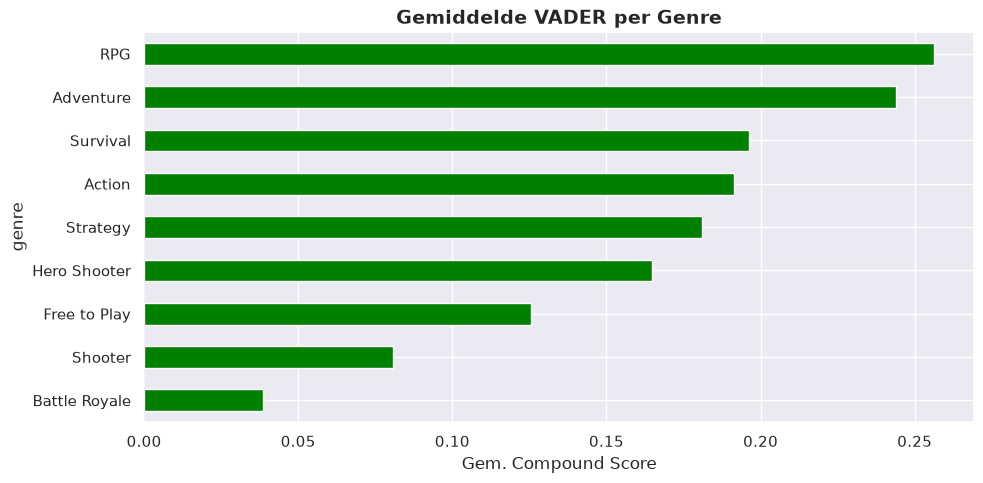

In [31]:
# VADER per genre
fig, ax = plt.subplots(figsize=(10, 5))
genre_sentiments = []
for genre in GENRE_IDS:
    g = df_vader[df_vader[f'genre_{genre}'] == 1]
    if not g.empty:
        genre_sentiments.append({'genre': genre.replace('_', ' '), 'avg_vader': g['vader_compound'].mean()})
gs_df = pd.DataFrame(genre_sentiments).sort_values('avg_vader')
colors_gs = ['red' if v < 0 else 'green' for v in gs_df['avg_vader']]
gs_df.set_index('genre')['avg_vader'].plot(kind='barh', ax=ax, color=colors_gs)
ax.set_title('Gemiddelde VADER per Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Gem. Compound Score')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
# TF-IDF per speletjie — top terme
top_terms = nlp_analysis.get_tfidf_per_game(df_vader, top_n=10)
for game, terms in list(top_terms.items())[:5]:
    print(f'\n{game}:')
    for term, score in terms:
        print(f'  {term}: {score}')



Elden Ring:
  game: 0.1115
  10: 0.0503
  like: 0.0384
  games: 0.0381
  just: 0.0349
  world: 0.0346
  play: 0.0343
  best: 0.0343
  souls: 0.0341
  time: 0.0337

Baldur's Gate 3:
  game: 0.1069
  10: 0.0404
  play: 0.0393
  story: 0.0383
  like: 0.036
  great: 0.0343
  just: 0.034
  games: 0.034
  best: 0.0338
  love: 0.0306

Counter-Strike 2:
  game: 0.1014
  cheaters: 0.0493
  play: 0.041
  good: 0.0338
  valve: 0.032
  just: 0.0302
  like: 0.0295
  10: 0.0265
  fun: 0.025
  playing: 0.0235

Overwatch 2:
  game: 0.1036
  play: 0.0488
  overwatch: 0.0429
  fun: 0.0381
  just: 0.0368
  like: 0.0354
  good: 0.0289
  playing: 0.0286
  time: 0.0259
  blizzard: 0.0243

Marvel Rivals:
  game: 0.1125
  play: 0.0521
  fun: 0.0443
  just: 0.0402
  matchmaking: 0.0389
  like: 0.0375
  good: 0.031
  team: 0.0289
  playing: 0.0284
  games: 0.0274


In [33]:
# TF-IDF per genre — top terme
print('=== Top TF-IDF Terme per Genre ===')
for genre in GENRE_IDS:
    terms = nlp_analysis.get_tfidf_by_genre(df_vader, f'genre_{genre}', top_n=10)
    if terms:
        print(f'\n{genre.replace("_", " ")}:')
        for term, score in terms:
            print(f'  {term}: {score}')


=== Top TF-IDF Terme per Genre ===

RPG:
  game: 0.1052
  just: 0.0364
  10: 0.036
  like: 0.035
  play: 0.0328
  good: 0.0321
  great: 0.0309
  fun: 0.0308
  games: 0.0303
  time: 0.0297

Shooter:
  game: 0.1092
  play: 0.0429
  fun: 0.0396
  just: 0.0352
  like: 0.0338
  good: 0.0332
  time: 0.0264
  playing: 0.0244
  10: 0.0235
  games: 0.0199

Hero Shooter:
  game: 0.1097
  play: 0.0474
  fun: 0.0463
  good: 0.0352
  just: 0.0346
  like: 0.0328
  overwatch: 0.029
  playing: 0.0258
  time: 0.0238
  10: 0.0237

Battle Royale:
  game: 0.1015
  play: 0.045
  fun: 0.0427
  good: 0.035
  just: 0.0349
  like: 0.0324
  games: 0.0238
  time: 0.023
  playing: 0.0206
  great: 0.0186

Action:
  game: 0.1076
  fun: 0.0366
  10: 0.036
  just: 0.036
  good: 0.0352
  play: 0.0349
  like: 0.0341
  story: 0.0317
  great: 0.0313
  games: 0.0284

Strategy:
  game: 0.1058
  play: 0.0387
  fun: 0.0358
  like: 0.0344
  just: 0.0328
  good: 0.0314
  great: 0.0284
  10: 0.028
  games: 0.0278
  time: 0.0266

### 4.2 Regressie-analise

In [34]:
# Lineêre regressie — voorspel VADER compound score
print('=== Lineêre Regressie: Voorspel VADER Sentiment ===')
print('Kenmerke: speeltyd, resensielengte, woordtelling, speletjie, genre, aankoop tipe, vroeë toegang')
lr = regression.linear_regression_model(df_vader)
print(f'R²: {lr["r2_score"]}')
print(f'RMSE: {lr["rmse"]}')
print(f'N trein: {lr["n_train"]}, N toets: {lr["n_test"]}')
print(f'\nTop 10 kenmerke:')
sorted_feats = sorted(lr['feature_importance'].items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for feat, coef in sorted_feats:
    print(f'  {feat}: {coef:+.4f}')


=== Lineêre Regressie: Voorspel VADER Sentiment ===
Kenmerke: speeltyd, resensielengte, woordtelling, speletjie, genre, aankoop tipe, vroeë toegang
R²: 0.0462
RMSE: 0.5507
N trein: 62700, N toets: 15676

Top 10 kenmerke:
  No_Mans_Sky: +0.0303
  Helldivers_2: -0.0284
  Baldurs_Gate_3: +0.0268
  Team_Fortress_2: +0.0263
  Fallout_4: -0.0260
  Destiny_2: +0.0260
  early_access: +0.0238
  Skyrim_SE: +0.0237
  Cyberpunk_2077: +0.0222
  votes_up: -0.0218


In [35]:
# Logistiese regressie — voorspel of review voted_up is
print('=== Logistiese Regressie: Voorspel Aanbeveling ===')
print('Kenmerke: speeltyd, resensielengte, woordtelling, VADER, speletjie, genre, aankoop tipe, vroeë toegang')
logit = regression.logistic_regression_voted_up(df_vader)
print(f'Akkuraatheid: {logit["accuracy"]:.2%}')
print(f'AUC-ROC: {logit["auc_roc"]:.3f}')
print(f'\nTop 10 kenmerke:')
sorted_feats = sorted(logit['feature_importance'].items(), key=lambda x: abs(x[1]), reverse=True)[:10]
for feat, coef in sorted_feats:
    print(f'  {feat}: {coef:+.4f}')
# Interpret: positiewe koëffisiënt = meer waarskynlik om aan te beveel


=== Logistiese Regressie: Voorspel Aanbeveling ===
Kenmerke: speeltyd, resensielengte, woordtelling, VADER, speletjie, genre, aankoop tipe, vroeë toegang
Akkuraatheid: 79.11%
AUC-ROC: 0.869

Top 10 kenmerke:
  review_length: -1.1015
  word_count: +0.7857
  votes_up: -0.6336
  Fallout_4: -0.5664
  Helldivers_2: -0.5099
  early_access: +0.4570
  Elden_Ring: +0.4269
  Valheim: -0.4139
  Cyberpunk_2077: +0.3636
  Ghost_of_Tsushima: +0.3499


In [36]:
# Per-genre suksesfaktor analise
print('=== Wat Voorspel Sukses Binne Elke Genre? ===')
for genre in GENRE_IDS:
    factors = eda.genre_success_factors(df_vader, genre)
    if factors:
        print(f'\n{genre.replace("_", " ")}:')
        for feat, coef in sorted(factors.items(), key=lambda x: abs(x[1]), reverse=True):
            print(f'  {feat}: {coef:+.4f}')


=== Wat Voorspel Sukses Binne Elke Genre? ===

RPG:
  word_count: -0.0007
  review_length: +0.0001
  playtime_forever: -0.0000

Shooter:
  word_count: -0.0003
  playtime_forever: -0.0000
  review_length: -0.0000

Hero Shooter:
  word_count: -0.0008
  playtime_forever: -0.0000
  review_length: +0.0000

Battle Royale:
  word_count: -0.0039
  review_length: +0.0006
  playtime_forever: -0.0000

Action:
  word_count: -0.0004
  playtime_forever: -0.0000
  review_length: -0.0000

Strategy:
  word_count: -0.0007
  playtime_forever: -0.0000
  review_length: +0.0000

Adventure:
  word_count: -0.0009
  review_length: +0.0001
  playtime_forever: -0.0000

Survival:
  word_count: -0.0018
  review_length: +0.0002
  playtime_forever: -0.0000

Free to Play:
  word_count: -0.0011
  review_length: +0.0001
  playtime_forever: -0.0000


### 4.3 Genre Netwerke

Hoe verwant is die 9 genres? Drie netwerkgrafieke:

1. **Genre Verwantskap** — nodus = genre, kantlyn = gedeelde speletjies. Wys watter genres 'n familie vorm.
2. **Genre Kommentaar** — TF-IDF-sentroïede per genre, kantlyn = cosinus-ooreenkoms tussen vokabulêre. Wys watter genres dieselfde woorde in resensies gebruik (net die sterkste bande, bo gemiddeld + 0.5·std).
3. **Woordnetwerk** — top-woorde per genre, kantlyn = ko-voorkoms in resensies. Wys die 'tipe kommentaar' van elke genre.


In [ ]:
# 4.3.1 Genre Verwantskap (gedeelde speletjies)
G_rel = network.genre_relationship_network()
print(f'Nodusse: {G_rel.number_of_nodes()}, Kantlyne: {G_rel.number_of_edges()}')
for u, v, d in sorted(G_rel.edges(data=True), key=lambda x: -x[2]['weight'])[:8]:
    print(f'  {u} <-> {v}: {d["weight"]} gedeelde speletjies')

fig, ax = plt.subplots(figsize=(12, 8))
network.draw_network(G_rel, ax=ax, title='Genre Verwantskap: Gedeelde Speletjies',
                     draw_edge_labels=True)
plt.tight_layout()
plt.show()


In [ ]:
# 4.3.2 Genre Kommentaar-ooreenkoms (TF-IDF-sentroïede)
G_comm = network.genre_commentary_network(df_en)
print(f'Nodusse: {G_comm.number_of_nodes()}, Kantlyne: {G_comm.number_of_edges()}')
for u, v, d in sorted(G_comm.edges(data=True), key=lambda x: -x[2]['weight'])[:8]:
    print(f'  {u} <-> {v}: {d["weight"]}')

fig, ax = plt.subplots(figsize=(12, 8))
network.draw_network(G_comm, ax=ax, title='Genre Kommentaar: TF-IDF Vokabulêre',
                     draw_edge_labels=True)
plt.tight_layout()
plt.show()


In [ ]:
# 4.3.3 Woordnetwerk per genre (3x3 rooster)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for idx, genre in enumerate(GENRE_IDS):
    row, col = divmod(idx, 3)
    G_word = network.genre_word_network(df_en, genre)
    if G_word.number_of_nodes() > 0:
        network.draw_network(G_word, ax=axes[row, col],
                             title=genre.replace('_', ' '), node_size_max=1000)
    else:
        axes[row, col].set_title(genre.replace('_', ' '))
        axes[row, col].axis('off')
plt.suptitle('Woordnetwerke per Genre (ko-voorkoms van top-woorde)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.4 Interaktiewe Dashboard

Om die Streamlit-dashboard te begin, hardloop in die terminal:
```bash
cd dashboard
streamlit run app.py
```
Die dashboard het 4 tabs (Oorsig, NLP & Netwerke, Vergelyk, Voorspellings) met genre- en speletjie-filters.


## Opsomming van Sleutelbevindings

1. **Genres verskil dramaties in sentiment.** RPG's en Action-Adventure speletjies het die hoogste positiewe persentasies, terwyl Hero Shooters en Battle Royales die laagste het. 'n Nuwe ontwikkelaar moet hierdie verskille in ag neem — 'n gemiddelde RPG is al positiewer as 'n top-vrystelling in 'n versadigde genre soos Shooters.

2. **Speeltyd is die sterkste voorspeller van negatiwiteit.** Spelers met meer ure speeltyd is meer krities — hulle is meer belê en het hoër verwagtinge. Dit geld oor alle genres heen.

3. **Genre-families vorm verwantskappe.** Action, Adventure en RPG deel speletjies én dieselfde resensie-vokabulêre — 'n ontwikkelaar kan oor hierdie familie heen leer uit suksesfaktore. Shooters (Shooter, Hero Shooter, Battle Royale, Free-to-Play) vorm 'n tweede blok met hul eie bekommernisse soos "cheaters" en "balans".

4. **Woordkeuse verskil per genre.** TF-IDF en die woordnetwerke wys elke genre se unieke bekommernisse: RPG spelers praat oor "dialoog" en "verkenning", Shooter spelers oor "cheaters" en "balans". 'n Ontwikkelaar se kommunikasie moet by die genre se woordeskat pas.

5. **Spelersgetalle en resensiesentiment is swak gekorreleer.** 'n Speletjie kan swak resensies hê (Overwatch 2, Marvel Rivals) maar steeds baie spelers lok. Mense speel ten spyte van wat hulle sê.

### Gevolgtrekking vir 'n Speletjie-Ontwikkelaar
* Kies jou genre verstandig — die basislyn verskil grootliks.
* Vind jou genre-familie en leer uit hul suksesfaktore.
* Luister na die woorde wat jou genre se gemeenskap gebruik.
* Die mees belêde spelers is die mees kritiese — maar ook die lojaalste as jy verbeter.
